In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from utils import extract_time_features

In [2]:
DATA_DIR = Path('../../datasets/module_2/')

In [3]:
df = pd.read_csv(Path(DATA_DIR, 'feature_frame.csv'))

### Basic Data Checks

In [4]:
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [6]:
df.describe()

,variant_id,order_id,user_id,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
count,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,...,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06
mean,3.401250e+13,2.978388e+12,3.750025e+12,3.289342e+00,1.153669e-02,2.113868e-02,6.092589e-04,2.290188e-03,3.629864e-03,1.272808e-01,...,5.492182e-02,3.538562e-03,5.134091e-02,2.072549e+00,3.312961e+01,3.523734e+01,2.645304e+01,3.143513e+01,3.088810e+01,2.594969e+01
std,2.786246e+11,2.446292e+11,1.775710e+11,2.140176e+00,1.067876e-01,1.438466e-01,2.467565e-02,4.780109e-02,6.013891e-02,1.268378e-01,...,3.276586e-01,5.938048e-02,3.013646e-01,3.943659e-01,3.707162e+00,1.057766e+01,7.168323e+00,1.227511e+01,4.330262e+00,3.278860e+00
min,3.361529e+13,2.807986e+12,3.046041e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.599349e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.414214e+00,0.000000e+00,7.000000e+00,2.828427e+00
25%,3.380354e+13,2.875152e+12,3.745901e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.394416e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.000000e+01,2.319372e+01,3.000000e+01,2.800000e+01,2.427618e+01
50%,3.397325e+13,2.902856e+12,3.812775e+12,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.105178e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01,2.769305e+01,3.000000e+01,3.100000e+01,2.608188e+01
75%,3.428495e+13,2.922034e+12,3.874925e+12,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.352670e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,4.000000e+01,3.059484e+01,3.000000e+01,3.400000e+01,2.796118e+01
max,3.454300e+13,3.643302e+12,5.029635e+12,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,3.000000e+00,1.000000e+00,6.000000e+00,5.000000e+00,1.480000e+02,8.400000e+01,5.868986e+01,1.480000e+02,3.950000e+01,3.564191e+01


In [8]:
df.duplicated().sum()

np.int64(0)

### Summary of features
- `variant_id`: product identifier. Should not give any real representation of the problem (there seems to be similar numbers associated to `product_type`... so my first guess is that removing this feature over `product_type` would be valuable)
- `product_type`: type of product
```
    ['ricepastapulses', 'snacksconfectionery', 'dishwasherdetergent',
       'cleaningaccessories', 'fabricconditionerfreshener', 'coffee',
       'femininecare', 'bathroomlimescalecleaner', 'handsoapsanitisers',
       'tinspackagedfoods', 'toiletroll', 'kitchenrolltissues', 'binbags',
       'windowglasscleaner', 'homebaking', 'tea', 'jamhoneyspreads',
       'washingliquidgel', 'longlifemilksubstitutes', 'allpurposecleaner',
       'softdrinksmixers', 'condimentsdressings', 'babyfood6months',
       'kidssnacks', 'cookingingredientsoils', 'floorcleanerpolish',
       'cereal', 'driedfruitsnutsseeds', 'pickledfoodolives', 'catfood',
       'cookingsaucesmarinades', 'juicesquash', 'beer', 'kidsdental',
       'nappies', 'maternity', 'washingpowder', 'dental', 'haircare',
       'bathshowergel', 'kitchenovencleaner', 'wipescottonwool',
       'dogfood', 'babytoiletries', 'foodstorage', 'shavinggrooming',
       'petcare', 'deodorant', 'washingcapsules', 'bodyskincare',
       'delicatesstainremover', 'babyfood12months', 'facialskincare',
       'superfoodssupplements', 'dryingironing', 'premixedcocktails',
       'householdsundries', 'feedingweaning', 'babymilkformula',
       'nappypants', 'healthcarevitamins', 'airfreshener']
```
- `order_id`: identifier of the order. Similar to `variant_id`, don't expect to add a lot of meaning as a feature...
- `user_id`: identifier of the user. As with other identifiers... the information is expected to be embedded into other features...
- `created_at`: date at which the order was created. Similar to `order_date`, but incorporates the hour of the order. As seen, a feature to be extracted from `created_at` would be a `order_hour`, which represents an indicative of the time of the day.
- `order_date`: day at which the order was creater.
- `user_order_seq`: not sure what it stands for... maybe the number of times a users has entered to ordered (whether abandoned or no?)
- `outcome`: is the main target feature of the dataset. If a classification problem, it's the outcome of the order (complete or not). (either 0 or 1)
- `ordered_before`: bool whether first time ordering or not (either 0 or 1)
- `abandoned_before`: bool whether first time abandoning or not (either 0 or 1)
- `active_snoozed`: not sure for the moment what it can refer to... maybe a product that is not currently available but the user has added? (either 0 or 1)
- `set_as_regular`: regular product added to cart
- `normalised_price`: price or the product divided by a quantity to normalise the data
- `discount_pct`: percentage of discount applied to the product
- `vendor`: vendor of the product
- `global_popularity`: popularity factor of the product 
- `count_adults`: number of adults associated to the user
```
2.0    2825732
3.0      24441
4.0      13481
1.0      12828
5.0       4067
```
- `count_children`: number of children associated to the user
```
0.0    2790935
2.0      46033
1.0      32302
3.0      11279
```
- `count_babies`: number of babies associated to the user
```
0.0    2870356
1.0      10193
```
- `count_pets`: number of pets associated to the user
```
0.0    2773965
1.0      74436
2.0      28087
3.0       2362
6.0       1699
```
- `people_ex_baby`: users after having babies (e.g. after a period buying diapers, baby food...). Does this mean `count_children` increases by one and `count_babies` is reduced by one?
- `days_since_purchase_variant_id`: last day since the user bought the same product
- `avg_days_to_buy_variant_id`: average number of days that people buy a particular product
- `std_days_to_buy_variant_id`: standard deviation of days that people buy a particular product
- `days_since_purchase_product_type`: number of days since the user bought the same product type
- `avg_days_to_buy_product_type`: number of days on average which people buy the same product type
- `std_days_to_buy_product_type`: standard deviation of days on average which people buy the same product type



### Additional features
As seen in the `problem.ipynb`, the time of the purchase seems to play a part in the abandoned orders.
We'll add features to transform the datime into readable format for the ML model

In [10]:
df = extract_time_features(df, "created_at")

### EDA

<Axes: >

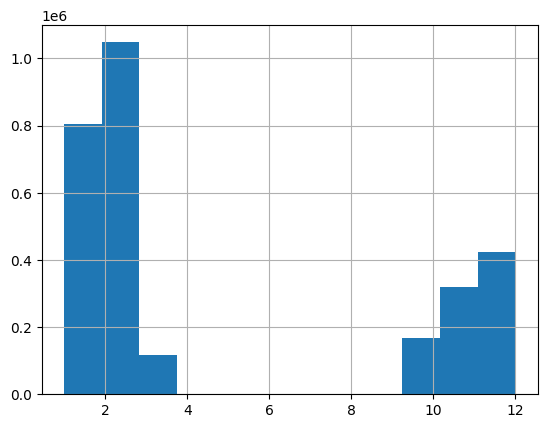

In [13]:
df["month"].hist(bins=12)

In [14]:
df["month"].value_counts()

month
2     1047726
1      804155
12     424135
11     318233
10     168403
3      117897
Name: count, dtype: int64

It's quite surprising to see that the data only tracks orders from October to March...

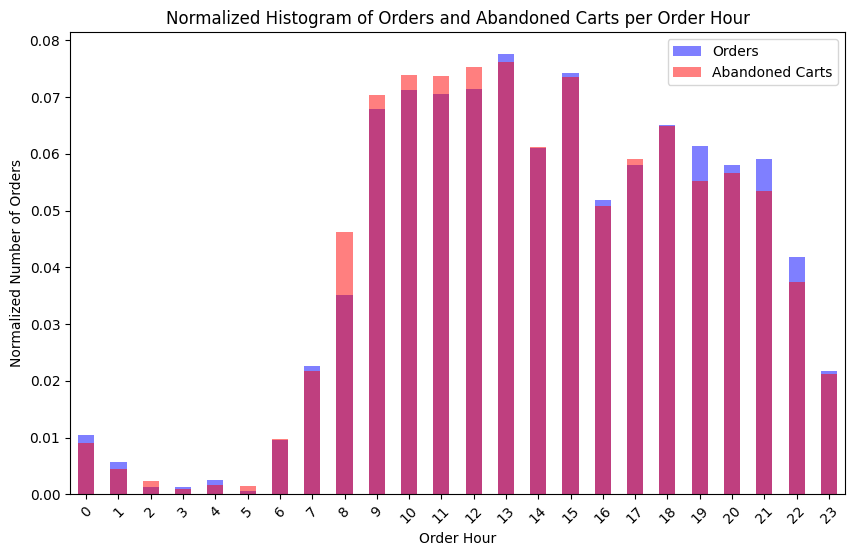

In [21]:
orders_hour_counts = df[df['outcome'] == 1]['hour'].value_counts().sort_index()
abandoned_carts_hour_counts = df[df['outcome'] == 0]['hour'].value_counts().sort_index()

orders_hour_counts_normalized = orders_hour_counts / orders_hour_counts.sum()
abandoned_carts_hour_counts_normalized = abandoned_carts_hour_counts / abandoned_carts_hour_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))
orders_hour_counts_normalized.plot(kind='bar', alpha=0.5, color='blue', label='Orders', ax=ax)
abandoned_carts_hour_counts_normalized.plot(kind='bar', alpha=0.5, color='red', label='Abandoned Carts', ax=ax)

plt.xlabel('Order Hour')
plt.ylabel('Normalized Number of Orders')
plt.title('Normalized Histogram of Orders and Abandoned Carts per Order Hour')
plt.xticks(rotation=45)
plt.legend()
plt.show()

It's also surprising to check a different pattern to the original data (check `problem.ipynb`)... What is the reason of change in abandoned carts pattern?